<font color='blue'>  **4a _______________________ Convection of a Scalar  _______________** </font> <br>

In [1]:
from Grid import Grid  ;from ScalarCoeffs import ScalarCoeffs ;from BoundaryConditions import BoundaryLocation, DirichletBc, NeumannBc ;from LinearSolver import solve 
from Models import DiffusionModel, SurfaceConvectionModel, FirstOrderTransientModel, PressureForceModel , AdvectingVelocityModel , MassConservationEquation, UpwindAdvectionModel
%matplotlib inline
import matplotlib.pyplot as plt ;import numpy as np  ;from numpy.linalg import norm   

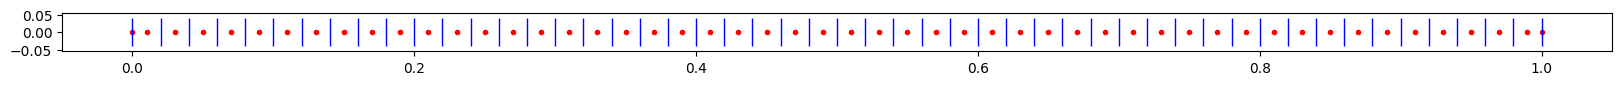

In [2]:
lx = 1.0 ;ly = 0.1 ;lz = 0.1 ;ncv = 50         ;grid = Grid(lx, ly, lz, ncv)            ;nTime = 1 ;dt = 1e9 ;time = 0  
maxIter = 10 ;converged = 1e-6                 ;rho = 1000 ;cp = 4000 ;k = 0.5        ;ho = 50   ;To = 200           # Thermophysical properties | Convection parameters

fig, ax = plt.subplots(figsize=(20, 0.5))       #;ax.set_xlim(grid.xf[0], grid.xf[int(len(grid.xf))-1])
ax.plot  (grid.xP, np.zeros_like(grid.xP), 'o',markersize=3,color='red')     ;ax.plot  (grid.xf, np.zeros_like(grid.xf), '|', markersize=20,color='b')      ;plt.show()

In [3]:
T0 = 300   ;T   = T0*np.ones(grid.ncv+2)   ;T_solns = [np.copy(T)]   ;maxIter = 100  ;coeffs = ScalarCoeffs(grid.ncv) ;converged = 1e-4     #  ;print('T',len(T),T)
U0 = 0.01  ;Uhe = U0*np.ones(grid.ncv+1)

west_bc = DirichletBc(T ,grid ,400 ,BoundaryLocation.WEST)  ;west_bc.apply()         ;east_bc = NeumannBc  (T ,grid, 0   ,BoundaryLocation.EAST)  ;east_bc.apply()  

Told = np.copy(T)       ;transient         = FirstOrderTransientModel (grid, T ,Told ,rho     ,cp, dt)          # Transient
k=100                   ;diffusion         = DiffusionModel           (grid ,T ,k    ,west_bc ,east_bc)                            
ho = 25 ;To = 200       ;surfaceConvection = SurfaceConvectionModel   (grid ,T ,ho   ,To)
n='n'                   ;advection         = UpwindAdvectionModel     (grid, T ,Uhe  ,rho, cp, west_bc, east_bc)

In [4]:
%%capture
for tStep in range(nTime):  
    time += dt      ;print("Timestep = {};Time = {}".format(tStep, time))     ;Told[:] = T[:]

    for i in range(maxIter):
        coeffs.zero()             ;coeffs=diffusion.add(coeffs)  ;coeffs=surfaceConvection.add(coeffs)  ;coeffs=advection.add(coeffs)        ;coeffs=transient.add(coeffs)
        n='n'                                                                                           ;maxResid = norm(coeffs.rP, np.inf)  ;avgResid = np.mean(np.absolute(coeffs.rP))  
        print("Iteration = {}                                                                           ;Max. Resid. = {}                    ;Avg. Resid. = {}".format(i, maxResid, avgResid))
        if maxResid < converged:   break
        dT = solve(coeffs)        ;T[1:-1] += dT                   ;west_bc.apply();east_bc.apply()     #;T_solns.append(np.copy(T))

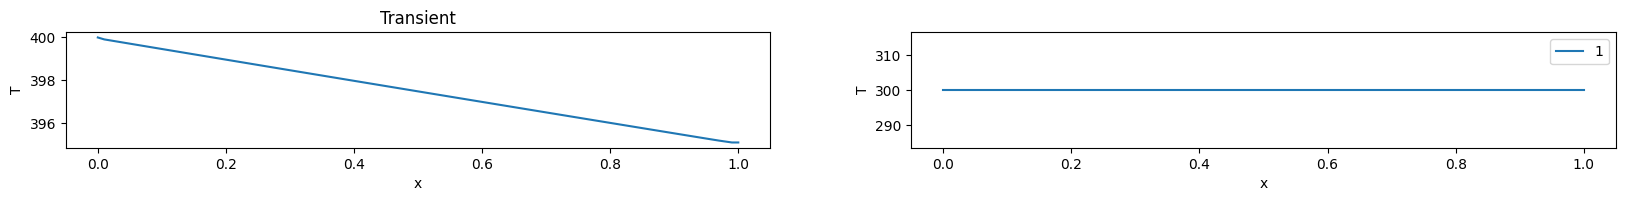

In [5]:
fig = plt.figure(figsize=(20, 1.5))                                               
ax = fig.add_subplot(121)      ;plt.plot(grid.xP, T) ;plt.xlabel("x") ;plt.ylabel("T")  ;plt.title("Transient")
ax = fig.add_subplot(122)  
for T in T_solns:               plt.plot(grid.xP, T, label=str(i));    i += 1
plt.xlabel("x");plt.ylabel("T");plt.legend();plt.show()

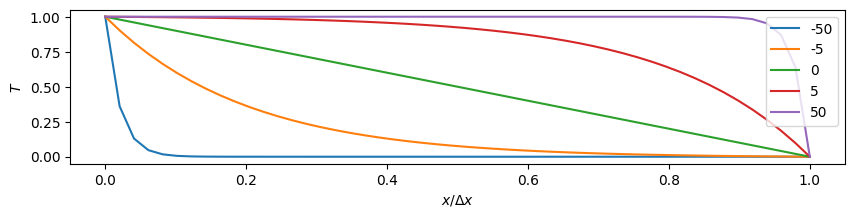

In [6]:
Pe_vals = [-50, -5, 1e-6, 5, 50]              ;x = np.linspace(0,1)                  ;TP = 1 ;TE = 0
plt.figure(figsize=(10, 2))
for Pe in Pe_vals:  
    T = (TE-TP) * (np.exp(Pe*(x-x[0]) / (x[-1]-x[0]))-1) / (np.exp(Pe)-1) + TP       ;plt.plot(x, T, label=str(int(Pe)))
plt.xlabel(r"$x/\Delta x$");plt.ylabel(r"$T$");plt.legend();plt.show()